Max-Min composition T (R∘S) =
 [[0.6  0.4  0.2 ]
 [0.8  0.45 0.2 ]]

Max-Product composition T (R∘S) =
 [[0.48  0.24  0.12 ]
 [0.648 0.324 0.162]]

Neuro-Fuzzy Max-Min composition T' =
 [[0.56629244 0.35570918 0.18439259]
 [0.69233951 0.37416043 0.18439259]]

Neuro-Fuzzy Max-Product composition T' =
 [[0.39206663 0.20143542 0.10442013]
 [0.53504647 0.27489539 0.14250033]]


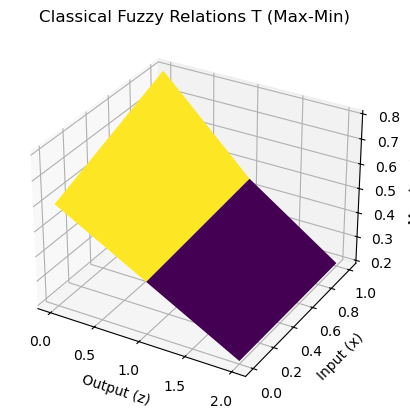

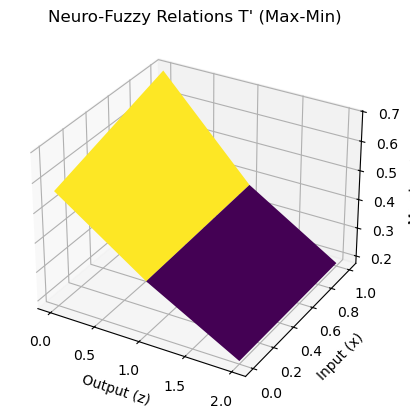

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# === 1. 定义模糊关系矩阵 R, S ===
R = np.array([[0.60, 0.25],
              [0.81, 0.45]])

S = np.array([[0.80, 0.40, 0.20],
              [0.10, 0.60, 0.10]])

# === 2. 定义模糊组合运算 ===

def max_min_composition(R, S):
    """最大-最小组合"""
    T = np.zeros((R.shape[0], S.shape[1]))
    for i in range(R.shape[0]):
        for j in range(S.shape[1]):
            T[i, j] = np.max(np.minimum(R[i, :], S[:, j]))
    return T

def max_product_composition(R, S):
    """最大-乘积组合"""
    T = np.zeros((R.shape[0], S.shape[1]))
    for i in range(R.shape[0]):
        for j in range(S.shape[1]):
            T[i, j] = np.max(R[i, :] * S[:, j])
    return T

# === 3. 计算经典模糊关系 ===
T_min = max_min_composition(R, S)
T_prod = max_product_composition(R, S)

print("Max-Min composition T (R∘S) =\n", T_min)
print("\nMax-Product composition T (R∘S) =\n", T_prod)

# === 4. 实现神经-模糊版本 ===
# 随机生成权重矩阵 WR, WS ∈ [0.8, 1.0]
WR = np.random.uniform(0.8, 1.0, R.shape)
WS = np.random.uniform(0.8, 1.0, S.shape)

# 加权矩阵
R_prime = WR * R
S_prime = WS * S

# 重新计算组合关系
T_min_prime = max_min_composition(R_prime, S_prime)
T_prod_prime = max_product_composition(R_prime, S_prime)

print("\nNeuro-Fuzzy Max-Min composition T' =\n", T_min_prime)
print("\nNeuro-Fuzzy Max-Product composition T' =\n", T_prod_prime)

# === 5. 绘制 3D 曲面图 ===
from mpl_toolkits.mplot3d import Axes3D

def plot_surface(matrix, title):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    x = np.arange(matrix.shape[1])
    y = np.arange(matrix.shape[0])
    X, Y = np.meshgrid(x, y)
    ax.plot_surface(X, Y, matrix, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Output (z)')
    ax.set_ylabel('Input (x)')
    ax.set_zlabel('Membership')
    plt.show()

# 绘图
plot_surface(T_min, "Classical Fuzzy Relations T (Max-Min)")
plot_surface(T_min_prime, "Neuro-Fuzzy Relations T' (Max-Min)")
